# 03 — Target list & the round-0 downselection figure
### *Rhodopseudomonas palustris* CGA009 (iRpa940) · PHB on p-coumarate

**This single notebook reproduces the entire target-selection pipeline and its one headline figure**
(*Round-0 CRISPRi targets — after downselection*). It runs end-to-end and depends only on the fixed model
(`Model/CGA009_model_biomass_fix.xml`, from notebook 01) plus the two shared modules in `lib/`
(`nb60_lib.py`, `nb71_lib.py`) and the vendored JBEI `FluxRETAP` library.

**Pipeline (each part writes a CSV the next part reads):**

| Part | Method / step | Output |
|---|---|---|
| 1 | **FVSEOF** — flux-response down-regulation scan | `nb60_fvseof_targets.csv` |
| 2 | **FluxRETAP** — JBEI 1/overlap flux-range shift | `nb61_fluxretap_targets.csv` |
| 3 | **CASOP** — yield-stratified importance (flux sampling) | `nb63_casop_targets.csv` |
| 4 | **Consensus + round-0 selection** (30 genes) | `nb64_master_target_table.csv`, `nb64_round0_selection.csv` |
| 5 | **Merge AI predictions + literature downselection → the figure** | `nb71_downselected_targets.csv`, `nb71_cut_list.csv`, `figures/nb71_downselected.png/.svg` |

**Reproducibility / determinism.** FVSEOF (Part 1) recomputes its FVA scan every run and is fully
deterministic (GLPK). FluxRETAP (Part 2) and CASOP (Part 3) load cached scans from
`Results/nb60_targets/*.pkl` by default (`FORCE_RERUN = False`); **keep CASOP cached** — its flux sampler
is not seeded, so recomputing can shift the list slightly. The AI-prediction column (Part 5) is a curated
literature table embedded in `lib/nb71_lib.py`. No commercial solver is needed (GLPK).

# Part 1 · FVSEOF — flux-response down-regulation targets
### *Rhodopseudomonas palustris* CGA009 (Alsiyabi, Immethun & Saha 2019, "iRpa940")

**Goal of this notebook (one method).** Predict single-gene **down-regulation (CRISPRi)** targets that
increase flux toward PHB using **FVSEOF** (Flux Variability Scanning based on Enforced Objective Flux).
This is the first of the three single-method scans; the consensus and selection steps come later in this notebook.

**FVSEOF in one line.** Enforce increasing PHB production and watch which reactions' flux must *fall* to
support it — those are knockdown candidates. FVSEOF augments the original FSEOF (Choi et al. 2010, *AEM*
76:3097) with flux-variability bounds so the scan reads a robust flux *range* rather than a single
(alternative-optima-sensitive) FBA value — exactly the Park et al. 2012 (*BMC Syst Biol* 6:106)
formulation.

**Clean-redo guarantees.** All logic is reimplemented in `nb60_lib.py` (no import of the prior-effort
`crispri_shared.py` / `phb_combo_lib.py`). The carbon source is set **explicitly to p-coumarate** — the
#1 bug in the prior pass was that the medium silently stayed on acetate (the model ships pinned to
`XR57=1.96` and the old `_configure()` never switched carbon).

## 1 · Medium, μmax and PHB IDs — confirm the model is set up correctly

Every non-trivial modeling choice and its source:

| Choice | Value | Grounding |
|---|---|---|
| Carbon source | p-coumarate, uptake `XR242` **unconstrained** (0–1000); acetate `XR57` **closed** | Alsiyabi 2019 feed it unconstrained and let light limit growth |
| Light | photon `XR55` lower −36.6 | Alsiyabi 2019 photon-limited point |
| N (growth state) | NH₃ `XR90` ≤ 10 (replete) | reference physiological state |
| O₂ | anaerobic (O₂ valves already 0) | *R. palustris* anaerobic photoheterotrophy |
| PHB readout | runtime sink `DM_C06143` (C06143 ⟶), bounds (0,1000) | sole readout of excess PHB; phaC `R04254` is the only producer |
| CO₂ | `XR72`/`XR73` open ±1000 | McKinlay & Harwood 2010 *PNAS*: CO₂ fixation is the dominant electron sink |

**Expected (paper):** μmax ≈ 0.077 1/h, doubling ≈ 9.4 h, coumarate self-limits to ≈ 0.33 mmol·gDW⁻¹·h⁻¹,
fed via the couAB route (`R01616` 4-coumarate:CoA ligase → `XR225` → acetyl-CoA).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))          # notebook runs from Notebooks/
import numpy as np, pandas as pd
import nb60_lib as L
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 46)

CARBON = "coumarate"

# --- confirm medium + mu_max + uptake self-limit + couAB route ---
gfluxes, mu_max = L.wt_growth_reference(CARBON)
mg = L.build_growth_state(CARBON)
print(f"GROWTH STATE (p-coumarate, NH3 replete)")
print(f"  mu_max             = {mu_max:.4f} 1/h   (paper ~0.077)")
print(f"  doubling time      = {np.log(2)/mu_max:.2f} h   (paper ~9.4)")
print(f"  coumarate XR242    = {gfluxes[L.COUMARATE_UP]:.4f} mmol/gDW/h   (paper self-limits ~0.33)")
print(f"  photon    XR55     = {gfluxes[L.PHOTON]:.4f}")
print(f"  couAB     R01616   = {gfluxes[L.COUAB_LIGASE]:.4f}  -> XR225 = {gfluxes['XR225']:.4f}")
print(f"  acetate   XR57     = {gfluxes[L.ACETATE_UP]:.4f}  (closed; should be 0)")
print(f"  open organic-C valves: {L.open_organic_carbon_audit(mg)}   (expect only coumarate)")

# --- confirm PHB IDs ---
prod = [r.id for r in mg.metabolites.get_by_id(L.PHB_MET).reactions
        if r.metabolites[mg.metabolites.get_by_id(L.PHB_MET)] > 0 and r.id != L.PHB_DEMAND]
mp = L.build_production_state(CARBON); phb_max = L.safe_slim(mp)
print(f"\nPHB IDs")
print(f"  PHB metabolite     = {L.PHB_MET} ({mg.metabolites.get_by_id(L.PHB_MET).name})")
print(f"  sink               = {L.PHB_DEMAND} bounds {mg.reactions.get_by_id(L.PHB_DEMAND).bounds}")
print(f"  phaC synthase      = {L.PHB_SYNTHASE}; sole C06143 producer? {prod == [L.PHB_SYNTHASE]} ({prod})")
print(f"  phaB reductase     = {L.PHB_REDUCT}")
print(f"  PHB_max (N-starved production state) = {phb_max:.4f} mmol/gDW/h")

GROWTH STATE (p-coumarate, NH3 replete)
  mu_max             = 0.0773 1/h   (paper ~0.077)
  doubling time      = 8.97 h   (paper ~9.4)
  coumarate XR242    = 0.3272 mmol/gDW/h   (paper self-limits ~0.33)
  photon    XR55     = 36.6000
  couAB     R01616   = 0.3272  -> XR225 = 0.3272
  acetate   XR57     = 0.0000  (closed; should be 0)
  open organic-C valves: [('XR242', '4-Coumarate', (0.0, 1000.0))]   (expect only coumarate)



PHB IDs
  PHB metabolite     = C06143 (Poly-beta-hydroxybutyrate)
  sink               = DM_C06143 bounds (0.0, 1000.0)
  phaC synthase      = R04254; sole C06143 producer? True (['R04254'])
  phaB reductase     = R01977
  PHB_max (N-starved production state) = 2.4920 mmol/gDW/h


## 2 · FVSEOF scan

**Algorithm (Park et al. 2012; Choi et al. 2010).**
1. Reference: max PHB at the growth state → `ceiling`.
2. **Enforced-objective scan:** for `f` in 10 points over 0.1→0.9, fix `DM_C06143 ≥ f·ceiling`
   (force increasing PHB), keep growth feasible.
3. At each point run **FVA at 95 % of the growth optimum** over all gene-associated reactions and take
   the flux **midpoint** `(min+max)/2`.
4. Per reaction fit `q_slope` = slope of midpoint vs enforced PHB; compute `r²` and a monotonicity
   fraction.
5. **Knockdown candidate** = `slope < 0` (flux must *fall* as PHB rises), keeping
   **`r² ≥ 0.70` AND `|q_slope| ≥ 0.05`**. The magnitude floor is essential: without it ~hundreds of
   flat housekeeping reactions pass; with it the count collapses to the validated ballpark (acetate gave
   ~21). Score = `|q_slope|·r²·monotonicity`.

*Down-regulation only:* we keep `slope<0` (knockdown), discarding `slope>0` amplification targets — those
are over-expression, not CRISPRi.

In [2]:
FVS_N, FVS_FVA_FRAC, FVS_MIN_R2, FVS_MIN_QSLOPE = 10, 0.95, 0.70, 0.05

meta = L.metadata()
cand = L.gene_candidates(meta)
print(f"gene-associated candidate reactions: {len(cand)}")

# reference PHB ceiling at the growth state
mref = L.build_growth_state(CARBON)
with mref:
    mref.objective = L.PHB_DEMAND
    ceiling = L.safe_slim(mref)
print(f"PHB ceiling (growth state) = {ceiling:.4f} mmol/gDW/h")

# enforced-objective scan -> FVA at each enforced PHB level
scan = {}
for f in np.linspace(0.1, 0.9, FVS_N):
    m = L.build_growth_state(CARBON)
    m.reactions.get_by_id(L.PHB_DEMAND).lower_bound = f * ceiling
    if L.safe_slim(m) < 1e-4:        # infeasible / no growth at this enforced PHB
        continue
    fva = L.safe_fva(m, cand, frac=FVS_FVA_FRAC)
    if fva is not None:
        scan[round(f * ceiling, 6)] = fva
levels = sorted(scan)
print(f"scan points kept: {len(levels)} enforced-PHB levels")

gene-associated candidate reactions: 909


PHB ceiling (growth state) = 2.4920 mmol/gDW/h


scan points kept: 10 enforced-PHB levels


In [3]:
# per-reaction slope fit of FVA midpoint vs enforced PHB
rows = []
for rid in cand:
    xs, yv = [], []
    for Lv in levels:
        if rid in scan[Lv].index:
            mn = float(scan[Lv].loc[rid, "minimum"]); mx = float(scan[Lv].loc[rid, "maximum"])
            yv.append((mn + mx) / 2.0); xs.append(Lv)
    if len(yv) < 3:
        continue
    xs = np.array(xs); yv = np.array(yv)
    slope, icept = np.polyfit(xs, yv, 1)
    yhat = slope * xs + icept
    ss_res = float(np.sum((yv - yhat) ** 2)); ss_tot = float(np.sum((yv - yv.mean()) ** 2))
    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    diffs = np.diff(yv)
    mono = (np.sum(diffs < 0) / len(diffs)) if slope < 0 else (np.sum(diffs > 0) / len(diffs))
    rows.append(dict(reaction=rid, name=meta["name"].get(rid, ""), genes=meta["genes"][rid],
                     subsystem=meta["subsys"].get(rid, ""), q_slope=slope, r2=r2, monotonicity=mono,
                     fvseof_score=abs(slope) * max(r2, 0) * mono,
                     direction="knockdown" if slope < 0 else "amplification"))
scored = pd.DataFrame(rows)
kd = scored[(scored.direction == "knockdown") & (scored.r2 >= FVS_MIN_R2)
            & (scored.q_slope.abs() >= FVS_MIN_QSLOPE)].copy()
print(f"scored reactions: {len(scored)}")
print(f"knockdown & r2>={FVS_MIN_R2} & |q_slope|>={FVS_MIN_QSLOPE}: {len(kd)}")

scored reactions: 909
knockdown & r2>=0.7 & |q_slope|>=0.05: 109


## 3 · Shared CRISPRi gene filter + 90 %-KD viability

Applied to every method so results are comparable:
- **gene filter** — keep reactions that (a) have a gene, (b) are not gapfilled, (c) are not transport/
  exchange (`XR*`/`EX_`), (d) are single-enzyme (no isozyme `or` in the GPR — one guide can't repress
  all isozymes); collapse duplicate reactions per gene set.
- **viability** — cap the reaction at 10 % of its WT growth-state flux (90 % KD) and require growth
  ≥ 10 % of WT μmax. Essential genes are kept as valid *partial*-KD targets (a full-KO gate would wrongly
  drop them).
- **PHB-pathway guard** — drop the positive-control reactions (`R04254` phaC, `R01977` phaB,
  `DM_C06143`) from the knockdown list. These are PHB *biosynthetic* steps; a flux-response scan can
  flag phaB as "decreasing" (its FVA band is driven down as enforced PHB rises — a sign artifact), but
  repressing it would *lower* PHB. Excluded across all methods.

In [4]:
kd = L.viability_filter(kd, gfluxes, mu_max, CARBON)
kd = L.crispri_gene_filter(kd, meta)
kd = L.drop_phb_pathway(kd)          # phaC/phaB/DM are positive controls, not knockdown targets
kd = kd.sort_values("fvseof_score", ascending=False).reset_index(drop=True)
print(f"FVSEOF final targets: {len(kd)}   (acetate reference ~21)")

    gene filter: 97 -> 52
    dropped 1 PHB-pathway positive-control rxn(s): ['R01977']
FVSEOF final targets: 51   (acetate reference ~21)


## 4 · FVSEOF predicted targets — raw (unnormalized) value

Bottom-line table for this method: gene, subsystem, name, and the **raw** prediction value
(`q_slope` = the unnormalized FVA-midpoint slope; negative = down-regulation), plus `r²`, monotonicity,
the composite `fvseof_score`, and the 90 %-KD growth fraction.

In [5]:
out = kd[["reaction", "genes", "subsystem", "name",
          "q_slope", "r2", "monotonicity", "fvseof_score", "kd_growth_frac"]].copy()
out.to_csv(L.OUT / "nb60_fvseof_targets.csv", index=False)
print(f"wrote {L.OUT / 'nb60_fvseof_targets.csv'}  ({len(out)} targets)")
out

wrote C:\Users\jscom\OneDrive\Documents\CGA009_GSM\Release_github\Results\nb60_targets\nb60_fvseof_targets.csv  (51 targets)


,reaction,genes,subsystem,name,q_slope,r2,monotonicity,fvseof_score,kd_growth_frac
0,R00004,RPA0411,Oxidative phosphorylation,Pyrophosphate phosphohydrolase (soluble),-0.413943,0.966407,1.000000,0.400038,1.000000
1,R01196,RPA4721,Citrate cycle (TCA cycle),pyruvate:ferredoxin 2-oxidoreductase (CoA-...,-0.272099,0.878343,1.000000,0.238996,0.938448
2,R00206,RPA1051,Pyruvate metabolism,"ATPpyruvate,orthophosphate phosphotransferase",-0.227021,0.962490,1.000000,0.218505,0.977717
3,R04386,RPA0071|RPA0508|RPA2435|RPA2436,Fatty acid biosynthesis,Acetyl-CoAcarbon-dioxide ligase (ADP-forming),-0.165294,0.994241,1.000000,0.164342,0.100000
4,R04385,RPA2435|RPA2436|RPA2936,Fatty acid biosynthesis,biotin-carboxyl-carrier-proteincarbon-diox...,-0.165294,0.994241,1.000000,0.164342,0.100000
5,R00921,RPA4567,Propanoate metabolism,acetyl-CoAphosphate acetyltransferase,-0.151348,0.993100,1.000000,0.150304,1.000000
6,R01821,RPA4727,Starch and sucrose metabolism,cpd00155 phosphorylase,-0.151348,0.993100,1.000000,0.150304,1.000000
7,R01253,RPA1580,Arginine and proline metabolism,Proline dehydrogenase,-0.129727,0.993100,1.000000,0.128832,1.000000
8,R01257,RPA1331,Pyruvate metabolism,(S)-Malate(acceptor) oxidoreductase,-0.129727,0.993100,1.000000,0.128832,1.000000
9,R01529,RPA3815,Pentose phosphate pathway,D-Ribulose-5-phosphate 3-epimerase,-0.231389,0.813117,0.666667,0.125431,0.995658


## 5 · Notes
- **What this method does:** ranks single down-regulation targets by how strongly a reaction's flux must
  decline (negative `q_slope`) as enforced PHB rises, with a robustness (`r²`) and magnitude floor.
- **Grounded in:** FSEOF — Choi et al. 2010 *AEM* 76:3097; FVSEOF (+GR variability) — Park et al. 2012
  *BMC Syst Biol* 6:106. Coumarate medium & photon 36.6 — Alsiyabi, Immethun & Saha 2019. CRISPRi 90 %-KD
  / 10 %-viability operating point as in the validated pipeline.
- **Couldn't verify / caveats:** `q_slope` is a model-specific ranker (flux-fraction proxy; the iRpa940
  model has no enzyme-capacity bounds — a GECKO ec-model would be more rigorous; CRISPRi is buffered in
  vivo, Donati et al. 2021). The magnitude floor (`|q_slope|≥0.05`) is calibrated, not first-principles.
- **Output** → `Results/nb60_targets/nb60_fvseof_targets.csv`, feeding the later consensus notebook.

# Part 2 · FluxRETAP — JBEI 1/overlap flux-range shift
### *Rhodopseudomonas palustris* CGA009 (iRpa940)

**Method.** FluxRETAP (JBEI; Tibocha-Bonilla et al.). For an enforced product (PHB) it runs FVA at
production checkpoints, fits a Gaussian to each reaction's flux range at the *initial* (PHB≈0) and
*final* (PHB≈max) checkpoints, and scores each reaction by **1/overlap** of those two Gaussians.
The **`Down`** trend (flux range shifts *lower* as PHB rises) gives genetic **down-regulation / CRISPRi**
targets — the use the JBEI group validated experimentally.

**The algorithm is the JBEI library, called verbatim.** `getRanges` (the FVA scan) and
`getFluxScoresTable` (the Gaussian 1/overlap scoring, `trend`, `fluxDiff`, `ors?`) are imported from
`FluxRETAP/core` and run **unmodified** — see the green rows of the ledger below. Only the *post-scoring
selection* is adapted for CRISPRi-on-coumarate, and **every adaptation is itemized with its reason and an
empirical demonstration** (§2). This mirrors what the validated acetate notebook (NB21) already did.

## Method-fidelity ledger — exactly what is and isn't changed

| Pipeline step | Canonical FluxRETAP (JBEI library) | What NB61 does | Why — and why it helps |
|---|---|---|---|
| **FVA range scan** | `getRanges(model, N, biomass, product, carbonSrc, frac, fast)` | 🟢 **identical call, unmodified library** (`N=10, fast=True` → checkpoints 0, 0.1, 0.9, 1.0; growth floor 10 %) | no change — this is the authors' computation |
| **Scoring** (1/overlap, `trend`, `fluxDiff`, `ors?`) | `getFluxScoresTable(model, ranges, subsystems)` | 🟢 **identical, unmodified library** | no change |
| **Normalizer arg** | the `carbonSourceRxn` arg only rescales FVA ranges by \|its flux\| | 🟢 pass **photon `XR55`** (constant −36.6) | same choice the validated acetate NB21 made; a constant normalizer keeps `fluxDiff` on a stable scale |
| **Isozyme exclusion** | `Ors=False` (drop GPRs containing `or`) | 🟡 keep `~ors?` **and** also drop transport/gapfilled + collapse by gene set | one CRISPRi guide can't repress isozymes; the extra drops just make the gate identical across all methods |
| **Effect-size gate** | `trend=='Down'` & `\|fluxDiff\| > 0.01` | 🟡 `trend=='Down'` & `\|fluxDiff\| ≥ 0.05` | **same gate, higher floor.** 0.01 lets ~flat housekeeping reactions through; 0.05 matches the FVSEOF effect-size floor so the methods are comparable |
| **Absolute score cutoff** | `score > 500` (library default) | 🔴 **dropped**; rank by `\|fluxDiff\|` instead | **coumarate-specific, proven in §2:** the reactions that clear `score>500` here have `fluxDiff≈1e-15` (narrow-FVA-range artifacts — gapfilled transports, tRNA ligases — with *no real flux change*), so the library's actual combined gate `score>500 & \|fluxDiff\|>0.01` returns **~0** targets. The 75 genuinely flux-shifting `Down` gene targets all score **413–472 (every one below 500)**. The library's own docs call 1/overlap a *weak model-specific ranker*; `\|fluxDiff\|` is the meaningful quantity here |
| **Viability** | `filterReactions` → full-KO `single_reaction_deletion`, keep `growth% > minGrowth` | 🔴 **90 %-KD partial-repression gate** (cap reaction at 10 % WT flux, require growth ≥ 10 % WT) | full KO is **infeasible→NaN** for *essential* genes, and `NaN > minGrowth` is always False, so the library gate silently deletes every essential candidate. CRISPRi is **partial** KD; essentials are valid partial-KD targets. (This is the exact swap the validated NB21 already made.) |
| **PHB-pathway** | not excluded | 🔴 drop phaC `R04254`, phaB `R01977`, `DM_C06143` | repressing PHB-synthesis steps *lowers* PHB — they are positive controls, not knockdown targets (consistent with NB60) |

🟢 unmodified library · 🟡 stricter/superset of the library default (safe) · 🔴 deliberate, documented change.

## 1 · Setup, medium confirm, and the JBEI FVA scan (`getRanges` + `getFluxScoresTable`)

FluxRETAP runs on the **production state** (N-starved, PHB-demand objective), as in the validated
pipeline. `getRanges` is expensive (FVA over all reactions × checkpoints) so it is cached to a pickle.

In [6]:
import sys, io, contextlib, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))              # notebook runs from Notebooks/
import numpy as np, pandas as pd
import nb60_lib as L
import core as retap                              # UNMODIFIED JBEI FluxRETAP library
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 46)

CARBON = "coumarate"
FORCE_RERUN = False   # set True to recompute the cached scan instead of loading it
N_CHECKPOINTS  = 10        # JBEI default; fast=True -> fractions 0, 0.1, 0.9, 1.0
FLUX_DIFF_MIN  = 0.05      # effect-size floor (raised from the library's 0.01; see ledger)
CACHE = L.OUT / "_fluxretap_coumarate_ranges.pkl"

# --- confirm medium (production state) ---
gfluxes, mu_max = L.wt_growth_reference(CARBON)
mp = L.build_production_state(CARBON)
print(f"production state (p-coumarate, N-starved): obj={mp.objective.expression.args[0]}")
print(f"  growth-state mu_max = {mu_max:.4f} 1/h | PHB_max = {L.safe_slim(mp):.4f} mmol/gDW/h")
print(f"  open organic-C valves: {L.open_organic_carbon_audit(mp)}")

ALL_SUB = set(r.subsystem for r in mp.reactions)
if CACHE.exists() and not FORCE_RERUN:
    ranges = pickle.load(open(CACHE, "rb"))
    print(f"loaded cached FVA ranges ({len(ranges)} checkpoints) <- {CACHE.name}")
else:
    print("running JBEI getRanges (unmodified) ...")
    with contextlib.redirect_stdout(io.StringIO()):
        ranges = retap.getRanges(mp, N_CHECKPOINTS, L.BIOMASS, L.PHB_DEMAND, L.PHOTON,
                                 L.MIN_GROWTH_FRAC, True)   # fast=True
    pickle.dump(ranges, open(CACHE, "wb"))
    print(f"  cached {CACHE.name}")

with contextlib.redirect_stdout(io.StringIO()):
    flux_scores, _, _ = retap.getFluxScoresTable(mp, ranges, ALL_SUB)   # unmodified
flux_scores["score"]    = pd.to_numeric(flux_scores["score"], errors="coerce")
flux_scores["fluxDiff"] = pd.to_numeric(flux_scores["fluxDiff"], errors="coerce")
print(f"scored {len(flux_scores)} reactions | Up={(flux_scores.trend=='Up').sum()} "
      f"Down={(flux_scores.trend=='Down').sum()}")

production state (p-coumarate, N-starved): obj=1.0*DM_C06143
  growth-state mu_max = 0.0773 1/h | PHB_max = 2.4920 mmol/gDW/h
  open organic-C valves: [('XR242', '4-Coumarate', (0.0, 1000.0))]
loaded cached FVA ranges (4 checkpoints) <- _fluxretap_coumarate_ranges.pkl


scored 1255 reactions | Up=428 Down=827


## 2 · Two checks before selecting

**(a) Positive control** — does the raw 1/overlap score recover the PHB pathway? phaC `R04254` / PHB
demand should sit at/near the top of the *raw* table (their flux is perfectly determined when PHB is
forced). If they do, the FVA scan is correctly wired to PHB on this model.

**(b) Why we drop `score>500`** — this cell *proves* the coumarate-specific problem the ledger claims.
The library's `filterReactions` applies `score>500` **together with** `|fluxDiff|>0.01`. We show that the
reactions clearing `score>500` have `fluxDiff≈0` (narrow-FVA-range artifacts), so the library's combined
default gate returns ~0 real targets — while the genuinely flux-shifting `Down` gene targets all score
*below* 500. Hence we keep the JBEI `|fluxDiff|` gate (raised to 0.05) and rank by `|fluxDiff|`.

In [7]:
meta = L.metadata()
# (a) positive control on the RAW score table
_fs = flux_scores.sort_values("score", ascending=False).reset_index()
_fs["rank"] = range(1, len(_fs) + 1)
print("Positive control — PHB-pathway reactions in the raw 1/overlap table:")
for rid in [L.PHB_SYNTHASE, L.PHB_REDUCT, L.PHB_DEMAND]:
    row = _fs[_fs["index"] == rid]
    if len(row):
        r = row.iloc[0]
        print(f"  {rid:11s} rank {int(r['rank']):4d}/{len(_fs)}  score={r['score']:.3g}  "
              f"trend={r['trend']}  fluxDiff={r['fluxDiff']:.3f}")
print("  PASS if phaC/PHB-demand are at/near the top.\n")

# (b) empirical justification for dropping the library's score>500 cutoff
down = flux_scores[(flux_scores.trend == "Down") & (~flux_scores["ors?"].astype(bool))].copy()
down["genes"] = [meta["genes"].get(r, "") for r in down.index]
down["name"]  = [meta["name"].get(r, "") for r in down.index]
is_gene = (down["genes"].str.len() > 0) & (down["genes"].str.lower() != "gapfilled") \
          & (~down.index.to_series().astype(str).str.match(r"^(XR|EX_)"))

hi = down[down.score > 500]
print(f"Down & single-enzyme reactions: {len(down)}")
print(f"  clear score>500: {len(hi)}  -- but look at their fluxDiff (the library ALSO requires "
      f"|fluxDiff|>0.01):")
print(hi[["score","fluxDiff","name"]].head(8).to_string())
hi_gene_fd = hi[hi.index.isin(down[is_gene].index)].fluxDiff.abs()
print(f"  -> top-scoring reactions have fluxDiff ~1e-15 (narrow-FVA-range artifacts); "
      f"max |fluxDiff| among the GENE-associated score>500 reactions = "
      f"{(hi_gene_fd.max() if len(hi_gene_fd) else 0.0):.2e}")

lib_default = down[(down.score > 500) & (down.fluxDiff.abs() > 0.01) & is_gene]
print(f"\n  LIBRARY combined default gate (Down & score>500 & |fluxDiff|>0.01 & gene): "
      f"{len(lib_default)} targets  <-- this is why we drop score>500")

act = down[is_gene & (down.fluxDiff.abs() >= FLUX_DIFF_MIN)]
fin = act.score.replace([np.inf, -np.inf], np.nan)
print(f"  OUR gate (Down & |fluxDiff|>={FLUX_DIFF_MIN} & gene): {len(act)} targets  "
      f"| their score band: {fin.min():.0f}-{fin.max():.0f} (median {fin.median():.0f}, all <500)")

Positive control — PHB-pathway reactions in the raw 1/overlap table:
  R04254      rank    6/1255  score=1.45e+11  trend=Up  fluxDiff=0.068
  R01977      rank  395/1255  score=449  trend=Down  fluxDiff=0.292
  DM_C06143   rank    7/1255  score=1.45e+11  trend=Up  fluxDiff=0.068
  PASS if phaC/PHB-demand are at/near the top.

Down & single-enzyme reactions: 635
  clear score>500: 48  -- but look at their fluxDiff (the library ALSO requires |fluxDiff|>0.01):
                  score      fluxDiff                                              name
R09489       502.963836  1.306891e-15  protoporphyrinogen IX:menaquinone oxidoreductase
R00480       506.594757  2.829078e-17               ATPL-aspartate 4-phosphotransferase
XR338        508.476558  6.845394e-17                                                  
XR200        514.995237  1.584722e-19                         Thiosulfate-ABC transport
XR293        515.885380  2.504790e-15                                                  
R05222     

## 3 · Select CRISPRi knockdown targets (documented selection)

Applying the ledger: the JBEI-computed `flux_scores` → `trend=='Down'` & `~ors?` & `|fluxDiff| ≥ 0.05`
→ shared gene filter → 90 %-KD viability → drop PHB-pathway controls → rank by `|fluxDiff|`.

In [8]:
sel = flux_scores[(flux_scores.trend == "Down")
                  & (flux_scores.fluxDiff.abs() >= FLUX_DIFF_MIN)
                  & (~flux_scores["ors?"].astype(bool))].copy()
print(f"JBEI Down & ~ors & |fluxDiff|>={FLUX_DIFF_MIN}: {len(sel)}")

ret = pd.DataFrame(dict(
    reaction=sel.index,
    name=[meta["name"].get(r, "") for r in sel.index],
    genes=[meta["genes"].get(r, "") for r in sel.index],
    subsystem=[meta["subsys"].get(r, "") for r in sel.index],
    retap_score=pd.to_numeric(sel["score"], errors="coerce").values,
    flux_diff=pd.to_numeric(sel["fluxDiff"], errors="coerce").values))
ret["abs_flux_diff"] = ret["flux_diff"].abs()

# 90%-KD viability (CRISPRi-appropriate; replaces the library's full-KO gate — see ledger)
ret = L.viability_filter(ret, gfluxes, mu_max, CARBON)
# shared gene filter: drop no-gene/gapfilled/transport/isozyme (collapse-by-gene done below by |fluxDiff|)
ret = L.crispri_gene_filter(ret, meta, collapse_by_gene=False)
ret = L.drop_phb_pathway(ret)
# collapse duplicate reactions per gene set, keeping the largest flux change (score is degenerate here)
ret = ret.sort_values(["abs_flux_diff", "retap_score"], ascending=False)
ret["_gs"] = ret["reaction"].map(lambda r: meta["genes"].get(r, ""))
ret = ret.drop_duplicates("_gs", keep="first").drop(columns="_gs").reset_index(drop=True)
print(f"FluxRETAP final targets: {len(ret)}   (acetate reference: a few-tens candidate set)")

JBEI Down & ~ors & |fluxDiff|>=0.05: 99


    gene filter: 90 -> 67
    dropped 1 PHB-pathway positive-control rxn(s): ['R01977']
FluxRETAP final targets: 53   (acetate reference: a few-tens candidate set)


## 4 · FluxRETAP predicted targets — raw (unnormalized) value

Bottom-line table: gene, subsystem, name, and the **raw** prediction value (`flux_diff` = the
JBEI-computed normalized flux-range shift; the ranking key), with the library's `retap_score` (1/overlap)
shown alongside and the 90 %-KD growth fraction.

In [9]:
out = ret[["reaction", "genes", "subsystem", "name",
           "flux_diff", "abs_flux_diff", "retap_score", "kd_growth_frac"]].copy()
out.to_csv(L.OUT / "nb61_fluxretap_targets.csv", index=False)
print(f"wrote {L.OUT / 'nb61_fluxretap_targets.csv'}  ({len(out)} targets)")
out

wrote C:\Users\jscom\OneDrive\Documents\CGA009_GSM\Release_github\Results\nb60_targets\nb61_fluxretap_targets.csv  (53 targets)


,reaction,genes,subsystem,name,flux_diff,abs_flux_diff,retap_score,kd_growth_frac
0,R03276,RPA0818,Fatty acid metabolism,(S)-3-Hydroxybutanoyl-CoA 3-epimerase,0.360437,0.360437,471.982909,0.999622
1,R01353,RPA4566,Propanoate metabolism,ATP:acetate phosphotransferase,0.194900,0.194900,449.232853,1.000000
2,R01137,RPA3056,Purine metabolism,ATPnucleoside-diphosphate phosphatransferase,0.194900,0.194900,448.010512,0.999958
3,R00206,RPA1051,Pyruvate metabolism,"ATPpyruvate,orthophosphate phosphotransferase",0.194900,0.194900,447.972769,0.977717
4,R01821,RPA4727,Starch and sucrose metabolism,cpd00155 phosphorylase,0.194900,0.194900,449.232853,1.000000
5,R00921,RPA4567,Propanoate metabolism,acetyl-CoAphosphate acetyltransferase,0.194900,0.194900,449.232853,1.000000
6,R01257,RPA1331,Pyruvate metabolism,(S)-Malate(acceptor) oxidoreductase,0.167057,0.167057,449.232853,1.000000
7,R01253,RPA1580,Arginine and proline metabolism,Proline dehydrogenase,0.167057,0.167057,449.232853,1.000000
8,R00004,RPA0411,Oxidative phosphorylation,Pyrophosphate phosphohydrolase (soluble),0.146175,0.146175,445.679883,1.000000
9,R02300,RPA3848|RPA3849,One carbon pool by folate,S-Aminomethyldihydrolipoylprotein:(6S)-tet...,0.146175,0.146175,449.232853,1.000000


## 5 · Notes
- **Unchanged:** the FluxRETAP algorithm itself — `getRanges` (FVA scan) and `getFluxScoresTable`
  (Gaussian 1/overlap, `trend`, `fluxDiff`, `ors?`) are the JBEI library called verbatim on the
  production state, with photon `XR55` as the FVA normalizer (as in the validated acetate NB21).
- **Changed, and why (see the ledger + §2 evidence):** (1) dropped the library's `score>500` cutoff —
  on coumarate it returns ~zero gene targets — and rank by `|fluxDiff|` (the library calls 1/overlap a
  weak model-specific ranker); (2) raised the `|fluxDiff|` floor 0.01→0.05 to match the other methods'
  effect-size floors; (3) replaced the full-KO viability gate with a 90 %-KD partial-repression gate
  (the library gate is NaN-incompatible with essential genes — same swap NB21 made); (4) dropped the
  PHB-pathway positive controls.
- **Grounded in:** FluxRETAP — Tibocha-Bonilla et al. / JBEI; coumarate medium — Alsiyabi 2019; CRISPRi
  90 %-KD / 10 %-viability operating point as in the validated pipeline.
- **Caveats:** 1/overlap is a weak ranker on this model (hence ranking by `|fluxDiff|`); flux-fraction
  KD proxy (no enzyme bounds; GECKO would be more rigorous); CRISPRi buffering (Donati et al. 2021).
- **Output** → `Results/nb60_targets/nb61_fluxretap_targets.csv`.

# Part 3 · CASOP — yield-stratified importance (flux sampling)
### *Rhodopseudomonas palustris* CGA009 (iRpa940)

**Method.** CASOP — Computational Approach for Strain Optimization (Hädicke & Klamt, *J Biotechnol* 2010).
CASOP ranks each reaction's **importance for product synthesis by weighting elementary modes (EMs) toward
high product yield**.

**Why a flux-sampling rendering.** There is no public Python/author code (CASOP lives in CellNetAnalyzer),
and **EMs do not enumerate at genome scale** — the combinatorial explosion is exactly why CASOP-GS itself
uses **EM *sampling***. This notebook renders the CASOP *principle* tractably via **flux sampling**: random
steady-state flux samples approximate convex combinations of EMs, so a reaction's yield-weighted importance
is read off how its usage differs between **low-yield** and **high-yield** sampled states.

**Score (CASOP knockout importance).** Sample the viable flux space (PHB free, growth ≥ 10 % of max),
stratify samples by **PHB yield** into thirds, and for each reaction compute
`casop_ko_score = mean|flux|(low-yield) − mean|flux|(high-yield)`. A **positive** score → the reaction
carries flux mainly when PHB yield is *low* → a **down-regulation / CRISPRi** candidate.

**Family.** This is the **yield-importance** family — a distinct signal from the flux-response
methods (FVSEOF/FluxRETAP). Honest caveat: it is a flux-sampling approximation of
EM-weighted CASOP, not the authors' EM implementation. Clean-redo: helpers from `nb60_lib.py`;
medium = p-coumarate.

### Two coumarate-specific adaptations (documented, with their evidence in §2)

A first pass using *absolute* PHB flux and the acetate-calibrated `0.05` floor returned only **2** targets.
Diagnosis (shown empirically in §2): (i) flux sampling explores the polytope's **bulk, not the high-PHB
vertices** — the sampler's max PHB is ~28 % of the feasible ceiling — so an *absolute*-PHB split gives a
weak contrast; (ii) the `0.05` floor was calibrated on **acetate**, and CASOP's score scale is genuinely
lower on coumarate, so `0.05` sits at the ~99.5th percentile (the same acetate-threshold-doesn't-transfer
problem we fixed for FluxRETAP's `score>500`). Two principled fixes:

| | First pass | This notebook | Why |
|---|---|---|---|
| **Stratify by** | absolute PHB flux | **PHB yield** (PHB / coumarate uptake) | CASOP is explicitly *yield*-weighted; yield separates the spectrum even when sampling is vertex-poor |
| **Selection floor** | absolute `ko ≥ 0.05` (acetate-calibrated) | **data-driven `mean + 2σ`** of the positive-score distribution | non-arbitrary; adapts to coumarate's score scale (cf. the FluxRETAP recalibration) |
| **Feedstock guard** | — | drop `R01616` (4-coumarate:CoA ligase) | repressing the catabolic feedstock entry cuts carbon *supply*, not a PHB redirection (it scores high only because high yield ⟺ low carbon throughput) |

## 1 · Sample the viable production space

Growth ≥ 10 % of µmax, PHB demand free → samples span low-PHB/high-growth to high-PHB/low-growth.
`OptGPSampler(processes=1, thinning=100)`, 5000 samples; cached (~minutes first run).

In [10]:
import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))
import numpy as np, pandas as pd
import nb60_lib as L
from cobra.sampling import OptGPSampler
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 46)

CARBON = "coumarate"
FORCE_RERUN = False   # set True to recompute the cached scan instead of loading it
N_SAMPLES, THINNING = 5000, 100
SAMPLE_CACHE = L.OUT / "_casop_coumarate_samples.pkl"
# Selection floor is data-driven (mean + N_SIGMA*sigma of the positive-score distribution), not a
# transplanted absolute. WITHOUT a floor (score>0) ~half the network qualifies (low-yield == high-growth
# noise tail); the data-driven floor keeps only reactions whose yield-stratified importance is
# statistically above background, and adapts to coumarate's score scale (see header table + §2).
N_SIGMA = 2.0

meta = L.metadata()
gfluxes, mu_max = L.wt_growth_reference(CARBON)
print(f"coumarate mu_max = {mu_max:.4f} 1/h | config:",
      dict(n=N_SAMPLES, thinning=THINNING, n_sigma=N_SIGMA))

if SAMPLE_CACHE.exists() and not FORCE_RERUN:
    S = pickle.load(open(SAMPLE_CACHE, "rb"))
    print(f"loaded cached samples: {S.shape[0]} x {S.shape[1]}")
else:
    m = L.build_growth_state(CARBON)
    m.reactions.get_by_id(L.BIOMASS).lower_bound = L.MIN_GROWTH_FRAC * mu_max     # viable space
    print("sampling (OptGP) ...")
    S = OptGPSampler(m, processes=1, thinning=THINNING).sample(N_SAMPLES)
    S = S[S[L.BIOMASS] >= L.MIN_GROWTH_FRAC * mu_max * 0.99]                       # keep viable
    pickle.dump(S, open(SAMPLE_CACHE, "wb"))
    print(f"  cached {SAMPLE_CACHE.name}: {S.shape[0]} samples")
phb = S[L.PHB_DEMAND]
print(f"PHB-demand across samples: min={phb.min():.3f} median={phb.median():.3f} max={phb.max():.3f}")

coumarate mu_max = 0.0773 1/h | config: {'n': 5000, 'thinning': 100, 'n_sigma': 2.0}
loaded cached samples: 5000 x 1255
PHB-demand across samples: min=0.001 median=0.080 max=0.645


## 2 · Yield-stratified reaction importance + the diagnosis behind the adaptations

First the evidence for the two adaptations: how far the sampler explores PHB vs the feasible ceiling
(why an *absolute*-PHB split is weak), then the yield stratification. Yield = PHB / coumarate-uptake;
split into low / high thirds; `casop_ko_score = mean|flux|(low-yield) − mean|flux|(high-yield)`.

In [11]:
# diagnosis: the sampler explores the bulk, not the high-PHB vertices
with L.build_growth_state(CARBON) as mc:
    mc.reactions.get_by_id(L.BIOMASS).lower_bound = L.MIN_GROWTH_FRAC * mu_max
    mc.objective = L.PHB_DEMAND; ceil = L.safe_slim(mc)
phb_s = S[L.PHB_DEMAND].values
print(f"feasible PHB ceiling @growth>=10% = {ceil:.3f} | sampled PHB max = {phb_s.max():.3f} "
      f"({phb_s.max()/ceil:.0%} of ceiling) -> absolute-PHB split is weak; use YIELD")

Aabs = S.abs()
cou = S[L.COUMARATE_UP].values.clip(min=1e-9)
yld = phb_s / cou                                   # PHB yield per carbon (the CASOP-faithful axis)
lo_cut, hi_cut = np.quantile(yld, 1/3), np.quantile(yld, 2/3)
lo = Aabs[yld <= lo_cut]; hi = Aabs[yld >= hi_cut]
print(f"low-yield samples: {len(lo)} (yield<={lo_cut:.3f}) | high-yield samples: {len(hi)} (yield>={hi_cut:.3f})")

ko = lo.mean() - hi.mean()                          # >0 => used more when yield low => KD target
rows = []
for rid in S.columns:
    g = meta["genes"].get(rid, "")
    if not g or g.lower() == "gapfilled":
        continue
    rows.append(dict(reaction=rid, name=meta["name"].get(rid, ""), genes=g,
                     subsystem=meta["subsys"].get(rid, ""), casop_ko_score=float(ko[rid]),
                     lo_use=float(lo[rid].mean()), hi_use=float(hi[rid].mean())))
scored = pd.DataFrame(rows)
print(f"scored {len(scored)} gene reactions | KO>0 (down candidates): {(scored.casop_ko_score>0).sum()}")

feasible PHB ceiling @growth>=10% = 2.283 | sampled PHB max = 0.645 (28% of ceiling) -> absolute-PHB split is weak; use YIELD
low-yield samples: 1667 (yield<=0.120) | high-yield samples: 1667 (yield>=0.256)
scored 909 gene reactions | KO>0 (down candidates): 426


## 3 · Positive control — phaC / phaB must be over-expression (negative KO score)

phaC `R04254` / phaB `R01977` carry flux mainly when PHB *yield* is *high*, so their KO score must be
**negative** (over-expression, not knockdown). If so, the yield stratification is oriented correctly.

In [12]:
for rid, lab in [(L.PHB_SYNTHASE, "phaC"), (L.PHB_REDUCT, "phaB")]:
    r = scored[scored.reaction == rid]
    if len(r):
        s = r.iloc[0]
        print(f"  {rid} ({lab}): KO_score={s.casop_ko_score:+.4f}  (lo_use={s.lo_use:.3f}, hi_use={s.hi_use:.3f})"
              f"  -> {'over-expression (good)' if s.casop_ko_score < 0 else 'KD?? check'}")
    else:
        print(f"  {rid} ({lab}): not scored (isozyme GPR -> excluded)")
print("\n  PASS if phaC/phaB have NEGATIVE KO score (used more when PHB is high).")

  R04254 (phaC): KO_score=-0.1455  (lo_use=0.038, hi_use=0.183)  -> over-expression (good)
  R01977 (phaB): KO_score=-0.1173  (lo_use=0.252, hi_use=0.369)  -> over-expression (good)

  PASS if phaC/phaB have NEGATIVE KO score (used more when PHB is high).


## 4 · CASOP CRISPRi targets

Drop PHB-pathway controls + the feedstock entry → shared gene filter → **data-driven `mean + 2σ` floor**
on the positive-score distribution (keeps reactions whose yield-stratified importance is statistically
above background) → 90 %-KD viability → rank by `casop_ko_score`.

In [13]:
# remove non-actionable reactions, then gene filter (isozyme/transport drop + collapse-by-gene)
cand = L.drop_feedstock(L.drop_phb_pathway(scored.copy()))
cand = L.crispri_gene_filter(cand, meta)
# data-driven floor: mean + N_SIGMA*sigma of the positive yield-importance scores (coumarate-appropriate)
pos = cand.casop_ko_score[cand.casop_ko_score > 0]
THR = float(pos.mean() + N_SIGMA * pos.std())
print(f"data-driven floor = mean+{N_SIGMA:g}sigma = {THR:.4f}  (over {len(pos)} positive gene reactions; "
      f"acetate's transplanted 0.05 would keep only {int((cand.casop_ko_score>=0.05).sum())})")
cs = cand[cand.casop_ko_score >= THR].copy()
print(f"above floor: {len(cs)}")
cs = L.viability_filter(cs, gfluxes, mu_max, CARBON)
cs = cs.sort_values("casop_ko_score", ascending=False).reset_index(drop=True)
print(f"CASOP final targets: {len(cs)}")

    dropped 2 PHB-pathway positive-control rxn(s): ['R01977', 'R04254']
    dropped 1 feedstock catabolic-entry rxn(s): ['R01616']
    gene filter: 906 -> 384
data-driven floor = mean+2sigma = 0.0285  (over 215 positive gene reactions; acetate's transplanted 0.05 would keep only 3)
above floor: 11


CASOP final targets: 11


## 5 · CASOP predicted targets — raw (unnormalized) value

Bottom-line table: gene, subsystem, name, and the **raw** prediction value (`casop_ko_score`, the ranking
key), with the low/high-PHB mean usage and the 90 %-KD growth fraction.

In [14]:
out = cs[["reaction", "genes", "subsystem", "name",
          "casop_ko_score", "lo_use", "hi_use", "kd_growth_frac"]].copy()
out.to_csv(L.OUT / "nb63_casop_targets.csv", index=False)
print(f"wrote {L.OUT / 'nb63_casop_targets.csv'}  ({len(out)} targets)")
out

wrote C:\Users\jscom\OneDrive\Documents\CGA009_GSM\Release_github\Results\nb60_targets\nb63_casop_targets.csv  (11 targets)


,reaction,genes,subsystem,name,casop_ko_score,lo_use,hi_use,kd_growth_frac
0,R01195,RPA1578,Carbon fixation in photosynthetic organisms,FerredoxinNADP+ oxidoreductase,0.107065,1.084456,0.977391,0.912250
1,R00127,RPA3229,Purine metabolism,ATPAMP phosphotransferase,0.069179,1.645057,1.575878,0.271061
2,R01196,RPA4721,Citrate cycle (TCA cycle),pyruvate:ferredoxin 2-oxidoreductase (CoA-...,0.068952,0.292340,0.223388,0.938448
3,R01900,RPA0202,Citrate cycle (TCA cycle),isocitrate hydro-lyase,0.049467,0.524365,0.474898,0.873185
4,R00351,RPA2907,Citrate cycle (TCA cycle),Citrate oxaloacetate-lyase ((pro-3S)-CH2CO...,0.049467,0.524365,0.474898,0.873185
5,R01353,RPA4566,Propanoate metabolism,ATP:acetate phosphotransferase,0.033932,0.389947,0.356015,1.000000
6,R00921,RPA4567,Propanoate metabolism,acetyl-CoAphosphate acetyltransferase,0.033932,0.389947,0.356015,1.000000
7,R02740,RPA3634,Glycolysis / Gluconeogenesis,D-Glucose-6-phosphate ketol-isomerase,0.033058,0.361306,0.328248,0.100000
8,R01528,RPA3635,Pentose phosphate pathway,6-Phospho-D-gluconateNADP+ 2-oxidoreductas...,0.032565,0.350932,0.318367,1.000000
9,R00835,RPA3636,Pentose phosphate pathway,D-Glucose-6-phosphateNADP+ 1-oxoreductase,0.032565,0.350932,0.318367,1.000000


## 6 · Notes
- **What this method does:** ranks reactions by **yield-stratified importance** — carries more flux when
  PHB yield is *low* ⇒ a knockdown candidate (the CASOP knockout-importance principle).
- **Grounded in:** CASOP — Hädicke & Klamt 2010 *J Biotechnol*; rendered via flux sampling because EMs do
  not enumerate at genome scale (CASOP-GS itself samples). Coumarate medium — Alsiyabi 2019.
- **Coumarate adaptations (documented, §2 evidence):** (1) stratify by **yield** (PHB/carbon), not
  absolute PHB — the sampler explores the bulk, not the high-PHB vertices; (2) **data-driven `mean+2σ`**
  selection floor, replacing the acetate-calibrated `0.05` (which returned only 2 because CASOP's score
  scale is lower on coumarate — the same acetate-threshold-doesn't-transfer issue fixed for FluxRETAP);
  (3) drop the feedstock entry `R01616` (repressing it cuts carbon supply, not a PHB redirection).
- **Caveats:** flux-sampling approximation of EM-weighted CASOP (not the authors' EM code); sampling is
  stochastic (cached for reproducibility within this run); flux-fraction KD proxy; CRISPRi buffering.
- **Family:** yield-importance — the third independent family for the family-weighted consensus.
- **Output** → `Results/nb60_targets/nb63_casop_targets.csv`.

In [15]:
# cross-method overlap snapshot
try:
    sets = {n: set(pd.read_csv(L.OUT / f).reaction) for n, f in [
        ("FVSEOF", "nb60_fvseof_targets.csv"), ("FluxRETAP", "nb61_fluxretap_targets.csv"),
        ("CASOP", "nb63_casop_targets.csv")]}
    cas = sets["CASOP"]
    for n in ["FVSEOF", "FluxRETAP"]:
        print(f"CASOP ∩ {n}: {len(cas & sets[n])}")
    print(f"CASOP-unique: {len(cas - sets['FVSEOF'] - sets['FluxRETAP'])}")
except Exception as e:
    print("overlap check skipped:", e)

CASOP ∩ FVSEOF: 6
CASOP ∩ FluxRETAP: 8
CASOP-unique: 2


# Part 4 · Consensus + round-0 target selection (30 genes)
### *Rhodopseudomonas palustris* CGA009 (iRpa940)

Combines the three down-regulation methods and **selects a diverse 30-gene round-0 target set**:
- **FVSEOF** (flux-response) · raw value = `q_slope`
- **FluxRETAP** (flux-response) · raw value = `flux_diff`
- **CASOP** (yield-importance) · raw value = `casop_ko_score`

(These three down-regulation methods — two flux-response, one yield-importance — are the ones carried
into the round-0 selection.)

**Why not a single consensus ranking?** A family-weighted consensus rewards *breadth* (moderate scores
across several methods) and can bury a method's single strongest call — e.g. FluxRETAP's #1 target, the
PHB-precursor epimerase `RPA0818`, never makes a consensus top-30. For an exploratory **round-0 screen** we
instead seed with each method's *clearly-ranked* picks, then collapse redundancy and diversify. The
selection (§3) is the 30-gene pool carried into the AI-merge and literature downselection in Part 5.

## 1 · Per-gene method support + raw predicted values

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nb60_lib as L
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 40); pd.set_option("display.max_rows", 200)

METHODS = {
    "FVSEOF":    ("nb60_fvseof_targets.csv",    "q_slope",        "flux-response"),
    "FluxRETAP": ("nb61_fluxretap_targets.csv", "flux_diff",      "flux-response"),
    "CASOP":     ("nb63_casop_targets.csv",     "casop_ko_score", "yield-importance"),
}
COLS = list(METHODS); FAMILY = {m: fam for m, (_, _, fam) in METHODS.items()}
meta = L.metadata()
GENE = lambda r: (meta["genes"].get(r, "") or "").split("|")[0]
NAME = lambda r: meta["name"].get(r, ""); SUB = lambda r: meta["subsys"].get(r, "")

raw, nrm, mag = {}, {}, {}
for m, (f, col, fam) in METHODS.items():
    d = pd.read_csv(L.OUT / f).reset_index(drop=True)        # already sorted best-first
    N = len(d)
    raw[m] = dict(zip(d.reaction, d[col]))
    nrm[m] = {r: 1.0 - i / N for i, r in enumerate(d.reaction)}
    a = d[col].abs(); lo, hi = a.min(), a.max()
    mag[m] = {r: (abs(v) - lo) / (hi - lo) if hi > lo else 1.0 for r, v in zip(d.reaction, d[col])}

allrx = [r for m in COLS for r in raw[m]]
allrx = list(dict.fromkeys(allrx))
rows = []
for r in allrx:
    ms = [m for m in COLS if r in raw[m]]; fams = sorted({FAMILY[m] for m in ms})
    fam_score = sum(max(nrm[m][r] for m in ms if FAMILY[m] == fam) for fam in fams)
    rows.append(dict(reaction=r, gene=GENE(r), subsystem=SUB(r), name=NAME(r),
                     methods="|".join(ms), n_methods=len(ms), consensus_score=round(fam_score, 4),
                     FVSEOF_q_slope=raw["FVSEOF"].get(r, np.nan),
                     FluxRETAP_flux_diff=raw["FluxRETAP"].get(r, np.nan),
                     CASOP_ko_score=raw["CASOP"].get(r, np.nan)))
master = pd.DataFrame(rows).sort_values(["n_methods", "consensus_score"], ascending=False).reset_index(drop=True)
master.to_csv(L.OUT / "nb64_master_target_table.csv", index=False)
print(f"{len(master)} unique targets across FVSEOF+FluxRETAP+CASOP | "
      f"multi-method: {(master.n_methods>=2).sum()}")

67 unique targets across FVSEOF+FluxRETAP+CASOP | multi-method: 43


## 2 · Assign each target to a metabolic module

A curated functional classifier (priority-ordered keyword/subsystem rules) places every target into one
metabolic module, so the selection reads as *biological strategy* (functional modules, not raw KEGG
subsystems — e.g. citrate synthase is grouped under *Acetyl-CoA conservation* for its PHB role).

In [17]:
MODULES = [("redox", ("Redox: ferredoxin /", "NAD(P)H balance")),
           ("backbone", ("Central carbon backbone", "(glycolysis / PEP)")),
           ("accoa", ("Acetyl-CoA conservation", "& PHB precursor")),
           ("ppp", ("Pentose phosphate", "(NADPH & precursors)")),
           ("tca", ("TCA cycle throttling", "")),
           ("aa", ("Amino-acid biosynthesis", "drains")),
           ("nuc", ("Nucleotide / energy", "charge")),
           ("other", ("Other / various", ""))]
MOD_COLOR = {"redox": "#3182bd", "backbone": "#2ca25f", "accoa": "#756bb1", "ppp": "#cc8b00",
             "tca": "#d9694a", "aa": "#2a9d8f", "nuc": "#b5539c", "other": "#8c8c8c"}
AA_SUBS = {"glycine, serine and threonine metabolism", "valine, leucine and isoleucine biosynthesis",
           "valine, leucine and isoleucine degradation", "lysine biosynthesis", "lysine degradation",
           "histidine metabolism", "methionine metabolism", "cysteine and methionine metabolism",
           "phenylalanine, tyrosine and tryptophan biosynthesis", "arginine and proline metabolism",
           "alanine, aspartate and glutamate metabolism", "glutamate metabolism", "beta-alanine metabolism",
           "tyrosine metabolism", "tryptophan metabolism", "urea cycle and metabolism of amino groups",
           "aminoacyl trna biosynthesis", "selenocompound metabolism"}
def module_of(r):
    nm = (NAME(r) or "").lower(); ss = (SUB(r) or "").lower()
    if "ferredoxin" in nm: return "redox"
    if any(k in nm for k in ["acetate phosphotransferase", "phosphate acetyltransferase",
            "citrate oxaloacetate-lyase", "malate glyoxylate-lyase", "hydroxybutanoyl",
            "carbon-dioxide ligase", "carboxyl-carrier", "acetyl-coa c-acetyltransferase"]): return "accoa"
    if ss == "pentose phosphate pathway" or any(k in nm for k in ["ribulose-5-phosphate",
            "ribose-5-phosphate", "6-phospho-d-gluconate", "glucono", "transketolase", "xylulose"]): return "ppp"
    if ss == "glycolysis / gluconeogenesis" or any(k in nm for k in ["2-phospho-d-glycerate hydro-lyase",
            "pyruvate,orthophosphate", "phosphoenolpyruvate", "glucose-6-phosphate ketol-isomerase",
            "3-phospho-d-glyceroyl"]): return "backbone"
    if ss in ("citrate cycle (tca cycle)", "glyoxylate and dicarboxylate metabolism") or any(
            k in nm for k in ["isocitrate", "(s)-malate", "fumarate", "succinate", "2-oxoglutarate",
            "citrate hydro-lyase"]): return "tca"
    if ss in AA_SUBS or "trna" in nm or "amidotransferase" in nm: return "aa"
    if ss in ("purine metabolism", "pyrimidine metabolism") or any(k in nm for k in [
            "amp phosphotransferase", "nucleoside-diphosphate", "pyrophosphate phosphohydrolase"]): return "nuc"
    return "other"
master["module"] = master.reaction.map(module_of)
print(master.groupby("module").size().to_dict())

{'aa': 7, 'accoa': 8, 'backbone': 5, 'nuc': 14, 'other': 13, 'ppp': 5, 'redox': 3, 'tca': 12}


## 3 · Round-0 target selection — per-method smart cutoffs + collapse + diversify

1. **Each method's clearly-ranked picks (smart cutoffs).** Every method's scores fall off into a
   *flux-coupled tie* (reactions carrying identical flux, which the method cannot rank); we keep each method
   down to that natural break — **FVSEOF top 10, FluxRETAP top 8** (its #1, `RPA0818`, stands far above the
   rest), **CASOP top 7** → ~17 high-confidence genes, including each method's individual champion.
2. **Collapse redundant pathway members** (keep the controlling step, per literature): the two
   acetyl-CoA-carboxylase subunits → one (`RPA0071`); the PTA-AckA pair → keep `pta` (`RPA4567`; `ackA`
   knockout causes toxic acetyl-phosphate buildup).
3. **Diversify to 30** with mostly *multi-method-supported* genes spanning strategies not yet covered —
   redox, NADPH/PPP (G6PDH = committed step), anaplerosis (PEPCK, malic enzyme), glutathione, lipid,
   propanoate, and amino-acid drains. (No glyoxylate-shunt genes here — kept out by choice.)

In [18]:
SHARP_N = {"FVSEOF": 10, "FluxRETAP": 8, "CASOP": 7}
sharp = set()
for m, (f, col, fam) in METHODS.items():
    d = pd.read_csv(L.OUT / f).reset_index(drop=True).head(SHARP_N[m])
    for g in d["genes"].astype(str): sharp.add(g.split("|")[0])
COLLAPSE = {"RPA2435", "RPA4566"}          # ACC 2nd subunit; ackA (keep RPA0071 + pta RPA4567)
sharp -= COLLAPSE
FILL = ["RPA0962", "RPA3634", "RPA0360", "RPA3173", "RPA3636", "RPA3042", "RPA0189", "RPA3834",
        "RPA0560", "RPA4211", "RPA0164", "RPA0822", "RPA4410", "RPA3450", "RPA0163"]
sel_genes = list(dict.fromkeys(list(sharp) + FILL))
g2rx = master.sort_values("consensus_score", ascending=False).drop_duplicates("gene").set_index("gene")["reaction"]
sel_rx = [g2rx[g] for g in sel_genes if g in g2rx.index]
selection = master[master.reaction.isin(sel_rx)].copy()
selection["source"] = selection.gene.map(lambda g: "sharp" if g in sharp else "fill")
selection["brightness"] = selection.reaction.map(lambda r: max([mag[m].get(r, 0.0) for m in COLS]))
selection.to_csv(L.OUT / "nb64_round0_selection.csv", index=False)
print(f"round-0 selection = {len(selection)} genes "
      f"({(selection.source=='sharp').sum()} sharp + {(selection.source=='fill').sum()} fill) | "
      f"multi-method: {(selection.n_methods>=2).sum()} | RPA0818 in: {'RPA0818' in set(selection.gene)}")
print("modules:", selection.module.value_counts().to_dict())
selection[["gene","name","module","methods","n_methods","source"]].sort_values(["module","source"])

round-0 selection = 30 genes (15 sharp + 15 fill) | multi-method: 24 | RPA0818 in: True
modules: {'tca': 5, 'aa': 5, 'accoa': 4, 'other': 4, 'backbone': 4, 'redox': 3, 'nuc': 3, 'ppp': 2}


,gene,name,module,methods,n_methods,source
20,RPA0560,malonyl-CoA carboxy-lyase (acetyl-Co...,aa,FVSEOF|FluxRETAP,2,fill
22,RPA4211,L-Glutamine amidohydrolase,aa,FVSEOF|FluxRETAP,2,fill
29,RPA0163,ATPL-glutamate 5-phosphotransferase,aa,FVSEOF|FluxRETAP,2,fill
30,RPA0164,L-Glutamate-5-semialdehydeNADP+ 5-ox...,aa,FVSEOF|FluxRETAP,2,fill
14,RPA1580,Proline dehydrogenase,aa,FVSEOF|FluxRETAP,2,sharp
1,RPA4567,acetyl-CoAphosphate acetyltransferase,accoa,FVSEOF|FluxRETAP|CASOP,3,sharp
7,RPA2907,Citrate oxaloacetate-lyase ((pro-3S)...,accoa,FVSEOF|CASOP,2,sharp
10,RPA0071,Acetyl-CoAcarbon-dioxide ligase (ADP...,accoa,FVSEOF|FluxRETAP,2,sharp
43,RPA0818,(S)-3-Hydroxybutanoyl-CoA 3-epimerase,accoa,FluxRETAP,1,sharp
15,RPA3173,3-Phospho-D-glyceroyl phosphate phos...,backbone,FVSEOF|FluxRETAP,2,fill


The 30-gene round-0 selection above is written to `nb64_round0_selection.csv`, and the full method×target table to `nb64_master_target_table.csv`. Part 5 loads both, merges the curated AI-prediction column, and renders the headline downselection figure. *(The intermediate per-module heatmaps from the original NB64 are omitted here — this notebook leads to the single downselection figure.)*

# Part 5 · Merge AI predictions + literature downselection → the figure
### *Rhodopseudomonas palustris* CGA009 (iRpa940)

Takes the combined **51-target** FBA+AI list (NB70) and trims it: within each group of targets doing the
**same job**, a deep literature search picks the best-in-class for CGA009 and cuts the redundant losers
(plus clear counter-evidence). **Two charts** — full (before) then fully-downselected (after) — and a **cut
list** with the reason for every removal.

**Cuts applied (10 → 41 kept).** Only *metabolic enzymes the model contains* are cut; the **5 regulators
(model-blind, no reaction in iRpa940) are kept** — orthogonal biology FBA can never surface.
| group | keep | cut | basis |
|---|---|---|---|
| redundant duplicates | pta, accA | ackA, fabH, fabF | pta = "key factor" (ΔackA → toxic acetyl-P); accA = committed FAS step (fabH/fabF downstream) |
| counter-evidence | — | RPA4394 isocitrate lyase, hbaA | glyoxylate shunt *retains* acetyl-CoA carbon; hbaA is on the main catabolic route (cuts supply) |
| **single-guide-infeasible** | — | **glnA** | GS = 4 dispersed isozymes (RPA0984/1401/2967/4209); one sgRNA → cell shifts to GlnA2 ([Microbiol Spectr 2023](https://pmc.ncbi.nlm.nih.gov/articles/PMC10100968/)) |
| N-sensor (metabolic) | — | gltB | GOGAT, secondary N-assimilation enzyme; the N-mimicry axis is already carried by the kept regulators |
| high-risk (metabolic) | FBA ferredoxin nodes | pntA, nuoF, atpA | redundant with model redox nodes + lethality risk (CGA009 obligately needs CBB/RuBisCO) |
| **regulators — KEPT** | **glnB, glnK, ntrB, nifA, regB** | — | **no reaction in iRpa940 → model-blind; kept as the orthogonal regulatory axis** |

*After cutting glnA, the N-starvation-mimicry strategy is carried by the kept regulators — `ntrB` is the
single-guide-feasible master lever (no paralog), while `glnB`/`glnK` are individually targetable but
PII-paralog-buffered. `gltB` (GOGAT) is single-guide-feasible via the shared RPA0891 subunit if you later
want a metabolic N-lever back.*

## 1 · Load the combined NB70 table (51 targets)

In [19]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))
import pandas as pd, matplotlib.pyplot as plt
import nb60_lib as L, nb71_lib as NB
pd.set_option("display.width", 260); pd.set_option("display.max_colwidth", 120)

rows, ai = NB.get_data()
PALETTE = "uw"   # colour scheme; options: uw (Husky purple+gold) | original | teal-clay | slate-amber | steel-rust
print(f"combined list = {len(rows)} targets  ({rows.source.value_counts().to_dict()})  | palette = {PALETTE}")

combined list = 51 targets  ({'FBA': 24, 'AI': 17, 'FBA+AI': 6, 'AI+FBA': 4})  | palette = uw


## 2 · Chart 1 — combined FBA + AI, **full list before downselection** (51)

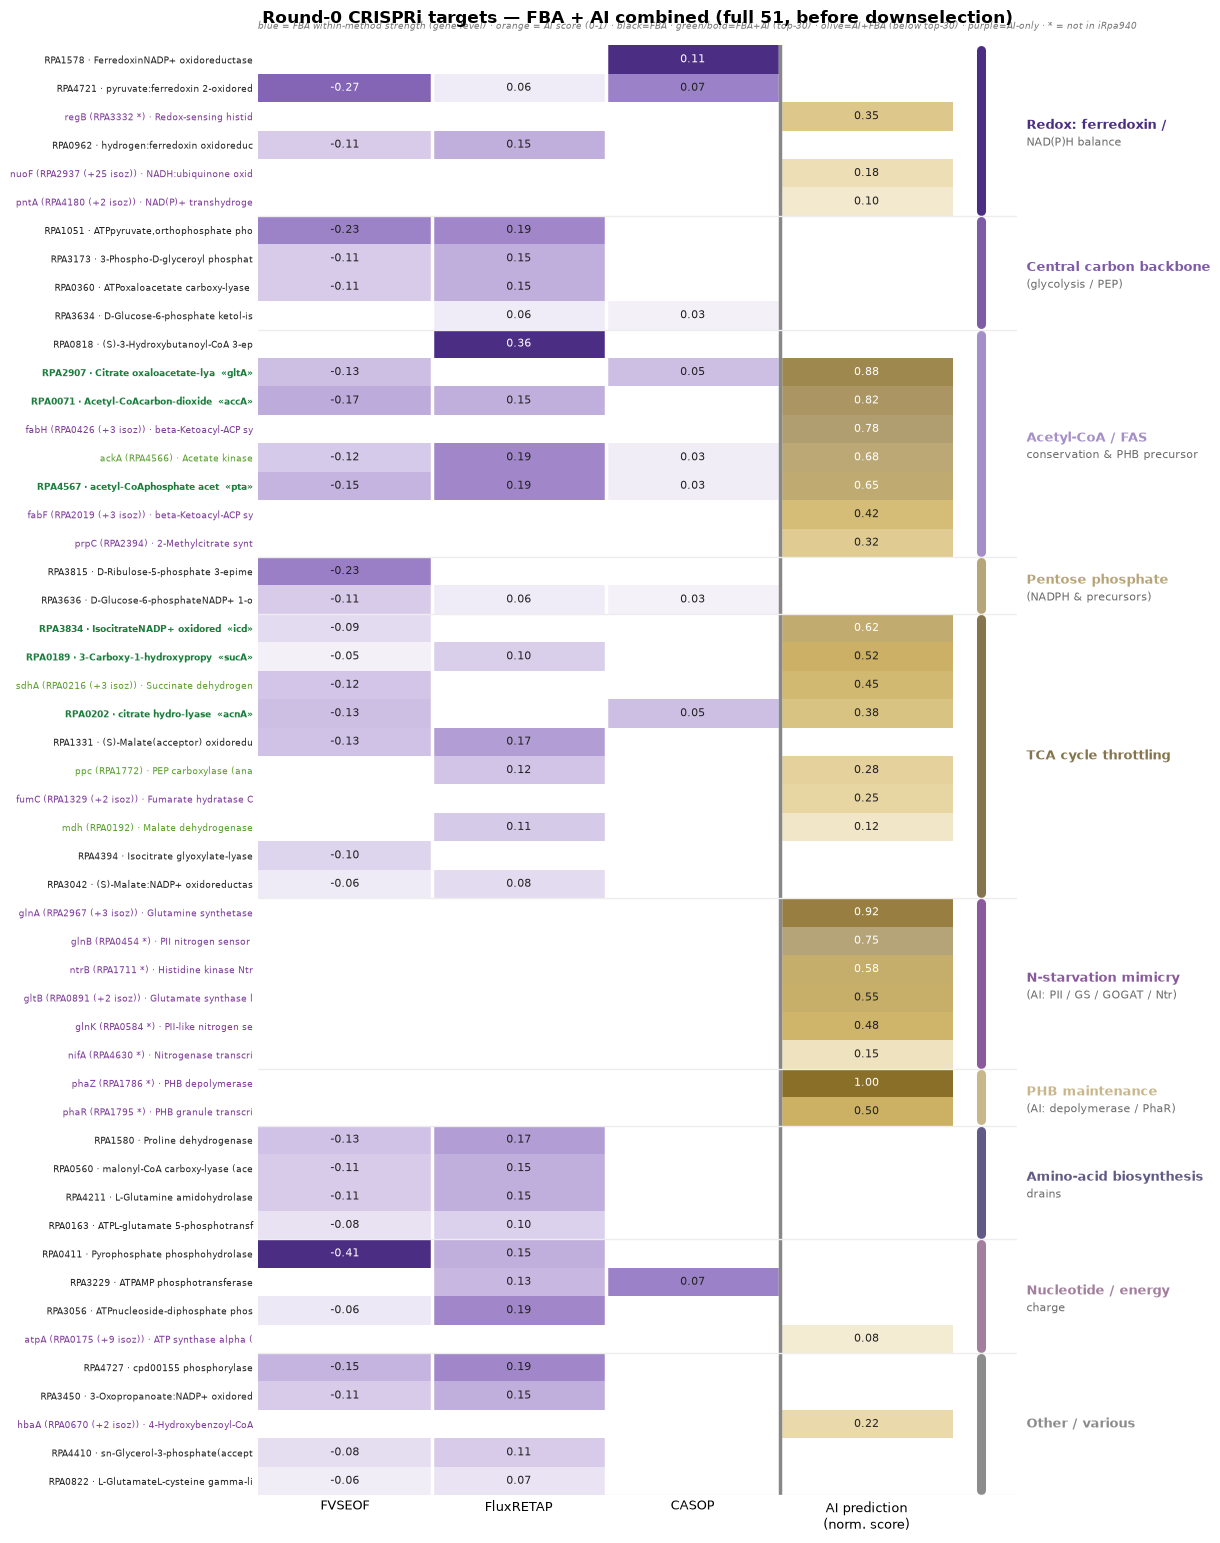

rendered nb71_full (51 genes)


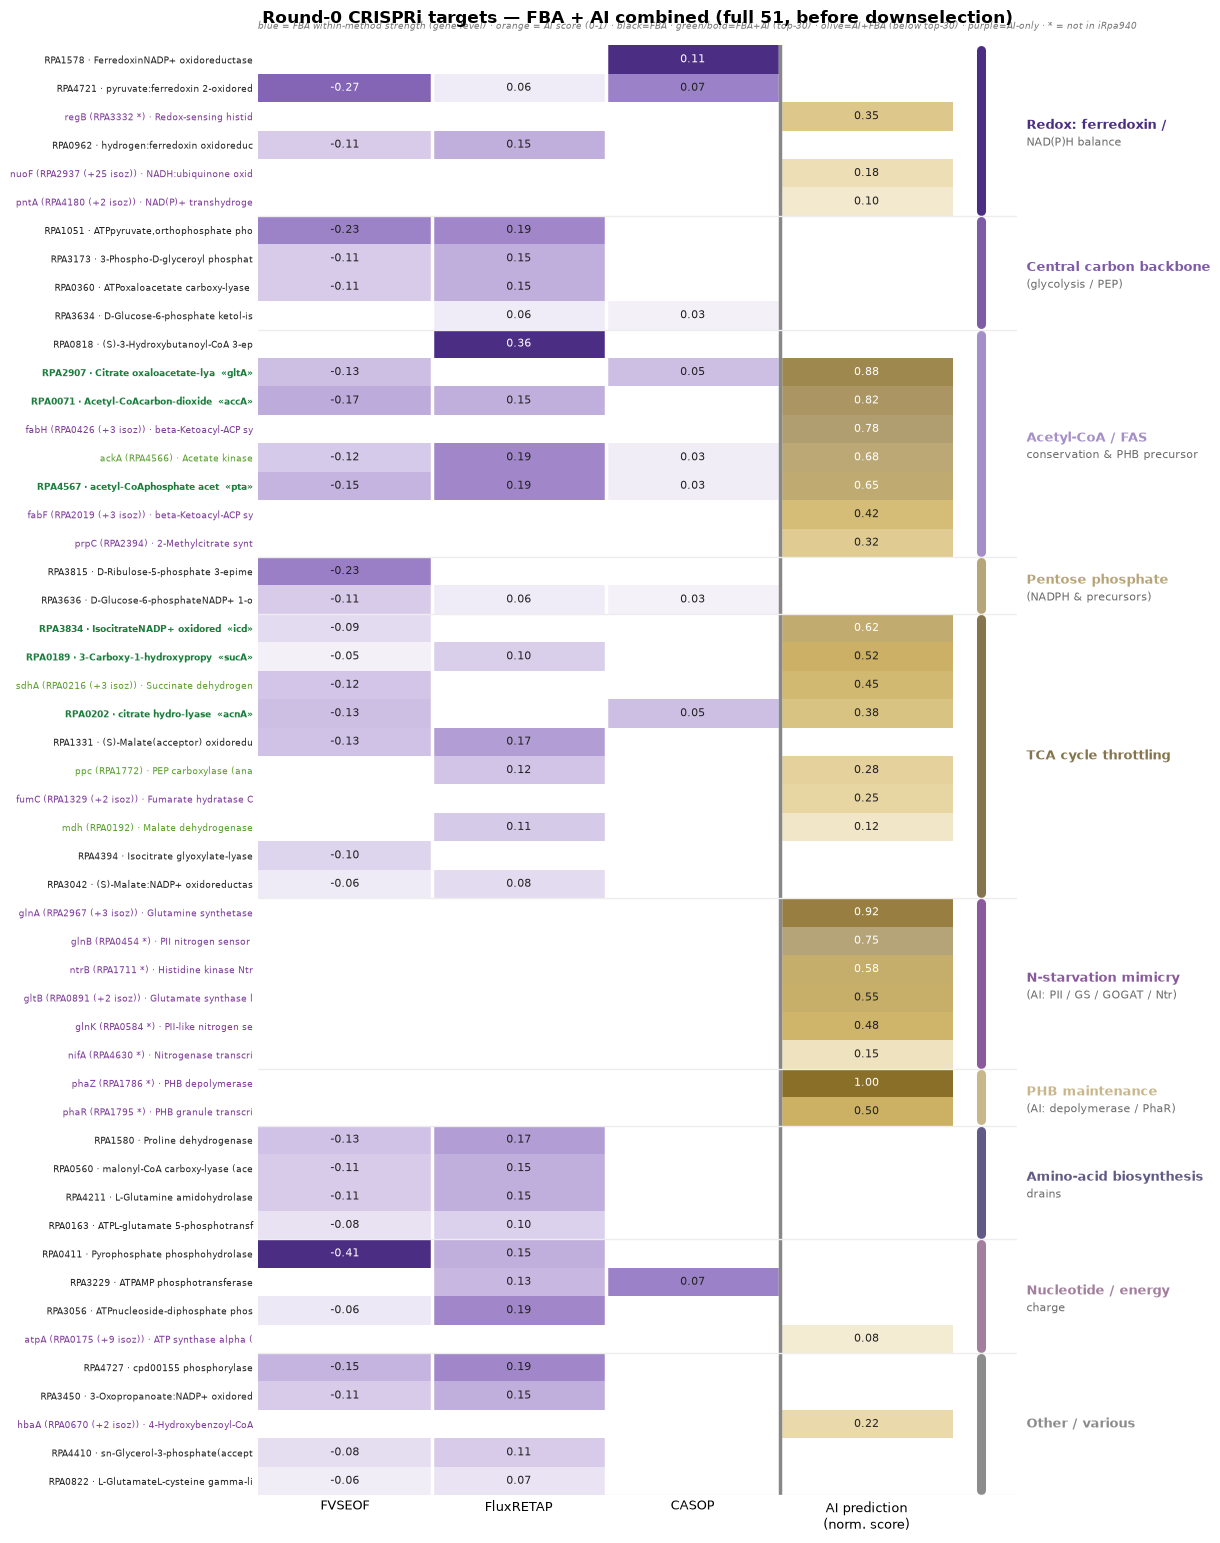

In [20]:
NB.heatmap(rows, "Round-0 CRISPRi targets — FBA + AI combined (full 51, before downselection)", "nb71_full", palette=PALETTE)

## 3 · Chart 2 — **after downselection** (41 kept)

`CUT_LIBRARY[model_locus] = (symbol, group, justification, citation)`. `GROUPS_TO_APPLY` selects which groups
are cut — the **`regulator (model-blind, KEPT)`** group is deliberately *excluded*, so those 5 regulators are
restored. To go heavier/lighter, add/remove a group name.

cut 10 of 51 -> 41 kept


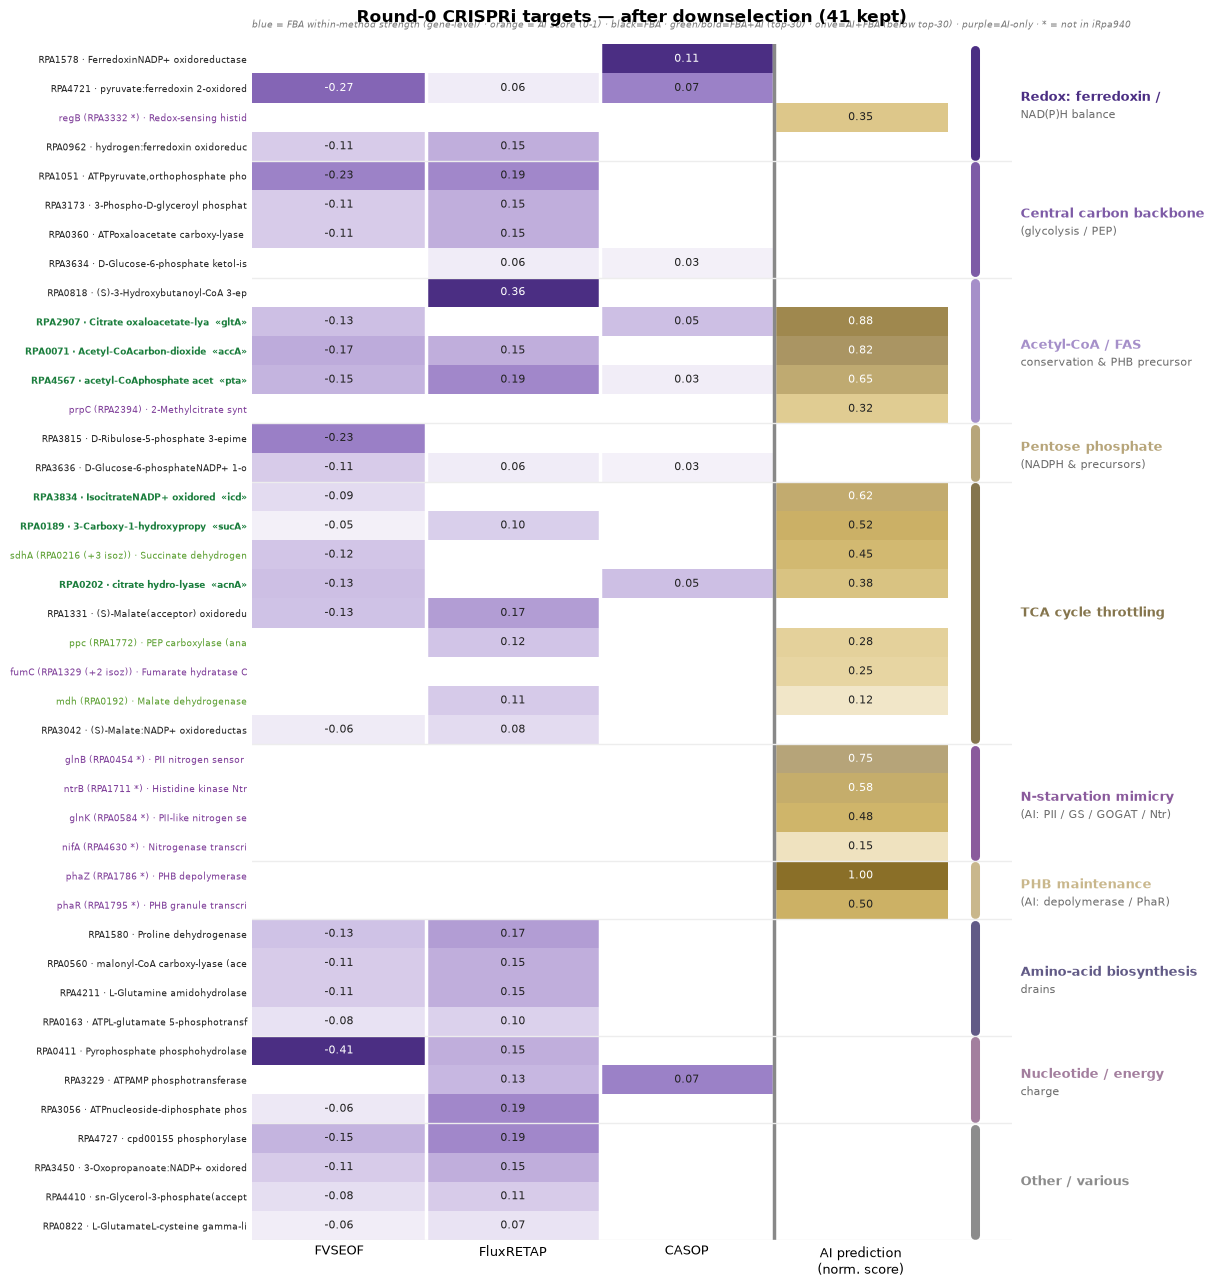

rendered nb71_downselected (41 genes)


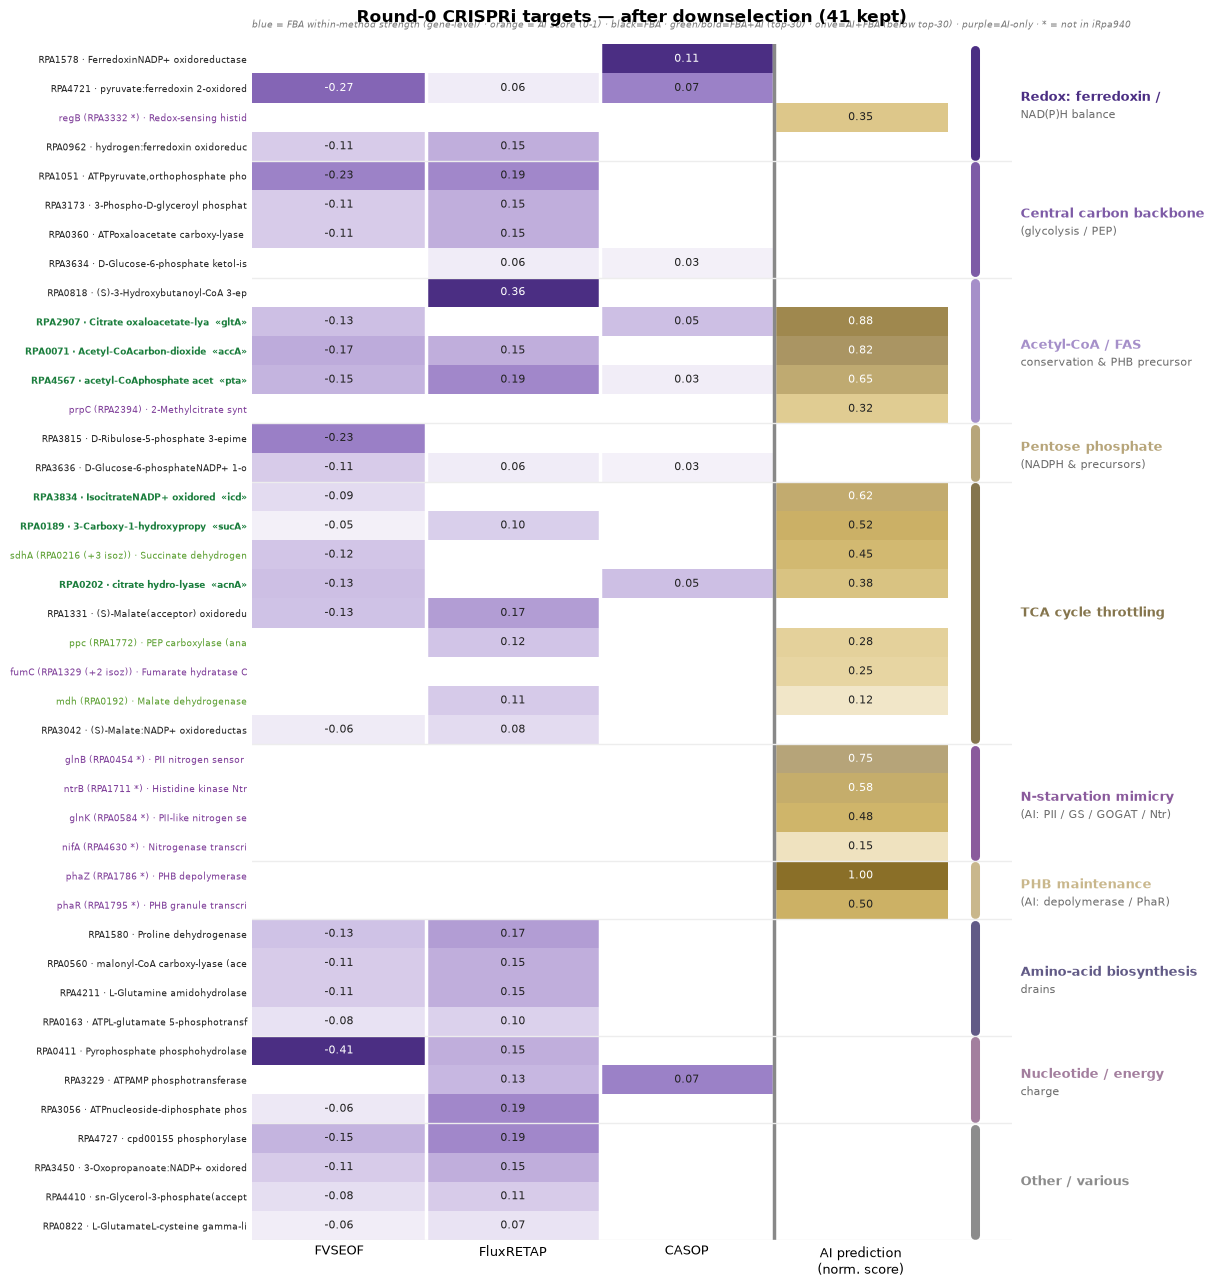

In [21]:
# model_locus -> (symbol, group, literature justification, citation)
CUT_LIBRARY = {
  "RPA4566": ("ackA", "redundant duplicate",
     "2nd step of the pta-ackA overflow pathway; knocking pta (upstream) already closes the valve and pta is FBA+AI consensus (3 methods). A lone ackA KD is worse: cells accumulate toxic acetyl-phosphate and pick up suppressor mutations.",
     "Kim 2010 (ackA instability, PMC3008541); phosphotransacetylase = key PHB factor"),
  "RPA0426": ("fabH", "redundant duplicate",
     "beta-ketoacyl-ACP synthase III (FAS initiation) is DOWNSTREAM of the committed ACC step; accA (kept) blocks the whole pathway and frees acetyl-CoA directly, so fabH adds nothing.",
     "Davis 2000; Heath & Rock 1996"),
  "RPA2019": ("fabF", "redundant duplicate",
     "beta-ketoacyl-ACP synthase II (FAS elongation), downstream of ACC; redundant with accA (FBA+AI consensus, RPA0071).",
     "Magnuson 1993; Cronan & Rock"),
  "RPA4394": ("isocitrate lyase (FBA)", "counter-evidence",
     "Glyoxylate-shunt entry. In R. palustris the glyoxylate shunt RETAINS the two acetyl-CoA carbons (avoids CO2 loss) and is the MAIN acetyl-CoA assimilation route; knocking it forces carbon into the CO2-losing lower TCA -> counterproductive for carbon-to-PHB, despite the FBA growth-coupling signal.",
     "McKinlay 2014 (JBC); McKinlay & Harwood 2010 (PNAS)"),
  "RPA0670": ("hbaA", "counter-evidence",
     "4-hydroxybenzoyl-CoA reductase sits on the MAIN p-coumarate -> 4-HBA -> benzoyl-CoA catabolic route; repressing it cuts carbon SUPPLY rather than redirecting it (same logic that excludes the couAB feedstock ligase).",
     "Egland 1997; Gibson & Harwood 2002"),
  # ---- single-guide-infeasible: isozyme redundancy means one sgRNA cannot knock down the FUNCTION ----
  # glnA (glutamine synthetase) is encoded by FOUR dispersed isozymes -> model GPR (R00253) =
  #   "RPA0984 or RPA1401 or RPA2967 or RPA4209".  A single guide silences only GlnA1 (RPA2967); the cell
  # then shifts to the alternative GlnA2 for NH4+ assimilation, so single-guide CRISPRi cannot lower GS
  # activity. Cut on FEASIBILITY, not merit.
  # SOURCE PAPER: "The Role of Glutamine Synthetase in Regulating Ammonium Assimilation and Iron-Only
  #   Nitrogenase Expression in a Photosynthetic Diazotroph", Microbiology Spectrum 11:e04953-22 (2023),
  #   doi:10.1128/spectrum.04953-22, PMID 36971559 / PMC10100968 -- "inactivation of GlnA1 makes
  #   R. palustris shift to use the alternative GlnA2 for ammonium assimilation".
  "RPA2967": ("glnA", "single-guide-infeasible (isozyme redundancy)",
     "GS function = 4 dispersed isozymes (GPR R00253 = RPA0984 or RPA1401 or RPA2967 or RPA4209); a single sgRNA on GlnA1 (RPA2967) leaves 3 GS genes and the cell shifts to GlnA2 for NH4+ assimilation, so single-guide CRISPRi cannot knock down GS activity. Cut on feasibility, not merit.",
     "Microbiol Spectr 11:e04953-22 (2023), doi:10.1128/spectrum.04953-22, PMID 36971559 (GlnA1 KO -> shift to GlnA2)"),
  "RPA0891": ("gltB", "N-sensor (metabolic)",
     "GOGAT, a secondary N-assimilation enzyme; the N-starvation-mimicry axis is already covered by the kept regulators (glnB/glnK/ntrB/nifA). Single-guide-feasible via the shared RPA0891 subunit, so available to restore if a metabolic N-lever is wanted.",
     "van Heeswijk 2013"),
  "RPA4180": ("pntA", "high-risk (metabolic)",
     "Transhydrogenase; redundant with the FBA-selected ferredoxin redox nodes (pyruvate:Fd oxidoreductase RPA4721 etc.), direction-dependent/uncertain, and redox-risky given CGA009's obligate CBB electron sink.",
     "Sauer 2004; Wang 2010 (obligate CBB)"),
  "RPA2937": ("nuoF", "high-risk (metabolic)",
     "Complex I; perturbing respiration is high-risk in CGA009, which obligately depends on CBB/RuBisCO as its electron sink (RuBisCO deletion is lethal photoheterotrophically). Redundant with FBA redox nodes.",
     "Wang 2010 (Arch Microbiol); Brandt 2006"),
  "RPA0175": ("atpA", "high-risk (metabolic)",
     "ATP synthase alpha; global energy-stress lever with ATP-burst/lethality risk and no model support. The AI itself flags it late-DBTL.",
     "Koebmann 2002; Otto 1993"),
  # ---- regulators: NO reaction in iRpa940 -> the model can never predict them. KEPT (not applied) as the
  #      orthogonal, model-blind regulatory axis, per user. (glnB/glnK/ntrB are a redundant N-sensor cluster
  #      if you want to trim within this group later; nifA is diazotrophic-only; regB is a global regulator.)
  "RPA0454": ("glnB", "regulator (model-blind, KEPT)",
     "PII nitrogen sensor with no reaction in iRpa940 -> FBA can never surface it. Orthogonal regulatory lever; kept. (Note: PII paralog, partially redundant with glnK.)",
     "Connolly 2006 (PubMed 16860774)"),
  "RPA0584": ("glnK", "regulator (model-blind, KEPT)",
     "PII-like nitrogen sensor, model-blind. Kept as orthogonal N-signalling lever (GlnK1 predominates under N-excess; interacts with AmtB).",
     "Connolly 2006; Detsch & Stuelke 2003"),
  "RPA1711": ("ntrB", "regulator (model-blind, KEPT)",
     "NtrB two-component histidine kinase, model-blind. Master N-limitation sensor; kept as the direct regulatory route to the N-starvation PHB program.",
     "Ninfa & Magasanik 1986"),
  "RPA4630": ("nifA", "regulator (model-blind, KEPT)",
     "Nitrogenase transcriptional activator, model-blind. Kept as a regulatory lever, but note it is only active under N2-fixing (diazotrophic) growth.",
     "Dixon & Kahn 2004"),
  "RPA3332": ("regB", "regulator (model-blind, KEPT)",
     "RegB/RegA global redox two-component regulator (>50 targets incl. PHA genes), model-blind. High-risk/high-reward but exactly the kind of global regulatory lever FBA cannot see; kept.",
     "Elsen 2004; Laguri 2003"),
}
# regulators (model-blind) are deliberately EXCLUDED here so they are RESTORED / kept:
GROUPS_TO_APPLY = {"redundant duplicate", "counter-evidence", "single-guide-infeasible (isozyme redundancy)",
                   "N-sensor (metabolic)", "high-risk (metabolic)"}

CUTS = {loc: v for loc, v in CUT_LIBRARY.items() if v[1] in GROUPS_TO_APPLY}
assert not [loc for loc in CUTS if loc not in set(rows.gene)], "cut locus not in table (typo)"
downselected = rows[~rows.gene.isin(CUTS)].reset_index(drop=True)
print(f"cut {len(CUTS)} of {len(rows)} -> {len(downselected)} kept")
NB.heatmap(downselected, f"Round-0 CRISPRi targets — after downselection ({len(downselected)} kept)", "nb71_downselected", palette=PALETTE)

## 4 · The cut list — every gene removed, and why

Plus the **restored regulators** (in `CUT_LIBRARY` but not applied) — kept because the model can never
predict them.

In [22]:
by_gene = rows.set_index("gene")
def entry(loc, sym, grp, why, cite):
    return {"symbol": sym, "model_locus": loc, "name": by_gene.loc[loc, "name"],
            "module": by_gene.loc[loc, "module"], "source": by_gene.loc[loc, "source"],
            "ai_score": by_gene.loc[loc, "ai_pred"], "fba_methods": by_gene.loc[loc, "fba_methods"],
            "group": grp, "justification": why, "citation": cite}
cut_tbl = pd.DataFrame([entry(loc, s, g, w, c) for loc, (s, g, w, c) in CUT_LIBRARY.items() if loc in CUTS]
                       ).sort_values(["group", "symbol"]).reset_index(drop=True)
kept_reg = pd.DataFrame([entry(loc, s, g, w, c) for loc, (s, g, w, c) in CUT_LIBRARY.items() if loc not in CUTS]
                        ).sort_values("symbol").reset_index(drop=True)
cut_tbl.to_csv(L.OUT / "nb71_cut_list.csv", index=False)
downselected.to_csv(L.OUT / "nb71_downselected_targets.csv", index=False)

print(f"CUT ({len(cut_tbl)} genes):\n")
for g, sub in cut_tbl.groupby("group"):
    print(f"-- {g} --")
    for _, r in sub.iterrows():
        print(f"  {r.symbol:10s} {r.model_locus:8s} {r['name'][:42]:42s}\n      {r.justification}\n      [{r.citation}]")
    print()
print(f"RESTORED / KEPT despite analysis ({len(kept_reg)} regulators, model-blind):\n")
for _, r in kept_reg.iterrows():
    print(f"  {r.symbol:10s} {r.model_locus:8s} {r['name'][:42]:42s}\n      {r.justification}\n")
print("saved nb71_cut_list.csv + nb71_downselected_targets.csv")

CUT (10 genes):

-- N-sensor (metabolic) --
  gltB       RPA0891  L-GlutamateNADP+ oxidoreductase (transamin
      GOGAT, a secondary N-assimilation enzyme; the N-starvation-mimicry axis is already covered by the kept regulators (glnB/glnK/ntrB/nifA). Single-guide-feasible via the shared RPA0891 subunit, so available to restore if a metabolic N-lever is wanted.
      [van Heeswijk 2013]

-- counter-evidence --
  hbaA       RPA0670  benzoyl-CoA:acceptor oxidoreductase       
      4-hydroxybenzoyl-CoA reductase sits on the MAIN p-coumarate -> 4-HBA -> benzoyl-CoA catabolic route; repressing it cuts carbon SUPPLY rather than redirecting it (same logic that excludes the couAB feedstock ligase).
      [Egland 1997; Gibson & Harwood 2002]
  isocitrate lyase (FBA) RPA4394  Isocitrate glyoxylate-lyase               
      Glyoxylate-shunt entry. In R. palustris the glyoxylate shunt RETAINS the two acetyl-CoA carbons (avoids CO2 loss) and is the MAIN acetyl-CoA assimilation route; knocking it 